# Entrega obligatoria — puntos f) y g)

Velocidad de descarga en función de la distancia al nodo.

Acá van la **prueba F** y el **análisis de residuos**.
Los puntos a) a e) están en `puntos_a_e.ipynb`.

In [2]:
import os, sys

# Nos paramos en la carpeta del notebook, asi encuentra regression.py y el Excel
# sin importar desde donde se haya abierto el proyecto.
try:
    carpeta = os.path.dirname(__vsc_ipynb_file__)   # VS Code
except NameError:
    carpeta = os.getcwd()                            # Jupyter clasico

if os.path.exists(os.path.join(carpeta, "regression.py")):
    os.chdir(carpeta)
    sys.path.insert(0, carpeta)

print("Carpeta de trabajo:", os.getcwd())

Carpeta de trabajo: c:\Users\Matil\Desktop\4to_2C\Diseno_de_Experimentos\Unidad 1\Entrega Obligatoria


In [3]:
from regression import RegresionVelocidadDistancia

regresion = RegresionVelocidadDistancia("../telecomunicaciones.xlsx")
res = regresion.run()

res.head()

,distancia,velocidad,ajuste,residuo
0,0.5,105.9,104.661505,1.238495
1,1.0,98.8,101.814965,-3.014965
2,1.5,101.7,98.968424,2.731576
3,2.0,105.3,96.121884,9.178116
4,2.5,90.4,93.275343,-2.875343


## El ajuste completo

`run()` devuelve la tabla con la distancia, la velocidad, el valor ajustado y el residuo.
Para ver el resumen del modelo armamos el ajuste con statsmodels:

In [4]:
import statsmodels.api as sm

X = sm.add_constant(res['distancia'])
modelo = sm.OLS(res['velocidad'], X).fit()

modelo.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:              velocidad   R-squared:                       0.947
Model:                            OLS   Adj. R-squared:                  0.945
Method:                 Least Squares   F-statistic:                     500.0
Date:                Wed, 26 Aug 2026   Prob (F-statistic):           2.13e-19
Time:                        19:35:36   Log-Likelihood:                -95.462
No. Observations:                  30   AIC:                             194.9
Df Residuals:                      28   BIC:                             197.7
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        107.5080      2.260     47.569      0.000     102.879     112.137
distancia     -5.6931      0.255    -22.360      0.000      -6.215      -5.172
==============================================================================
Omnibus:                        0.071   Durbin-Watson:                   2.041
Prob(Omnibus):                  0.965   Jarque-Bera (JB):                0.090
Skew:                           0.074   Prob(JB):                        0.956
Kurtosis:                       2.775   Cond. No.                         18.4
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

## Sumas de cuadrados

$$SCT = SCR + SCE$$

In [5]:
regresion.sct()

19230.894666666667

In [6]:
regresion.scr()

18211.028146829794

In [7]:
regresion.sce()

1019.8665198368556

In [8]:
regresion.n()

30

---

# f) Significación estadística de la pendiente

$$H_0: \beta_1 = 0 \qquad vs. \qquad H_1: \beta_1 \neq 0$$

$$F = \frac{SCR/1}{SCE/(n-2)}$$

In [9]:
regresion.f()

499.97600489209367

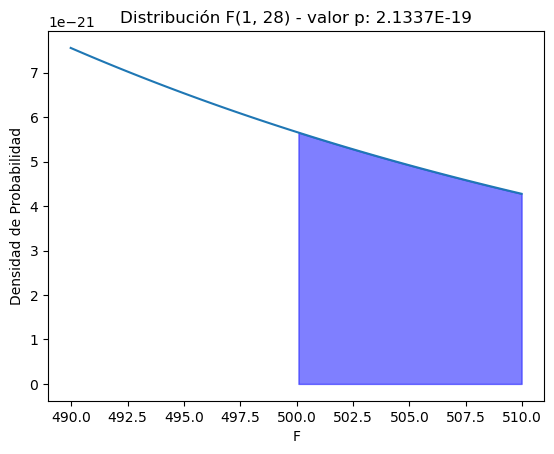

In [10]:
regresion.f_chart()

El valor observado **F = 499,98** con **p = 2,13 × 10⁻¹⁹**, así que se rechaza H₀:
**sí hay evidencia** de relación lineal entre la distancia al nodo y la velocidad de descarga.



---

# g) Análisis de los residuos

## Linealidad

Ajustamos una parábola y vemos si la mejora justifica el término de más.
Si el p-valor es grande, el modelo lineal alcanza:

In [11]:
F, p = regresion.linealidad()
print("F = %.4f   p = %.4f" % (F, p))

F = 2.5188   p = 0.1241


## Normalidad

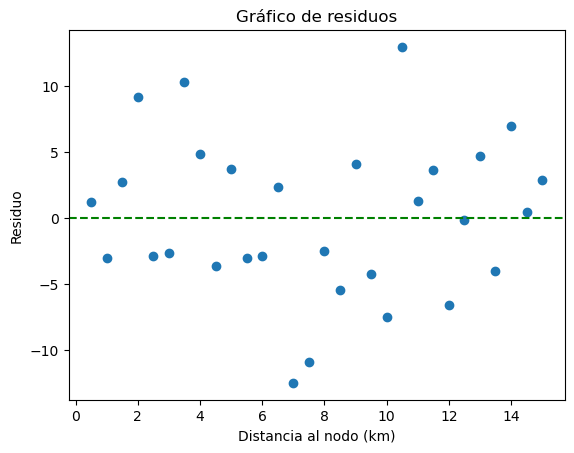

In [12]:
regresion.residuos()

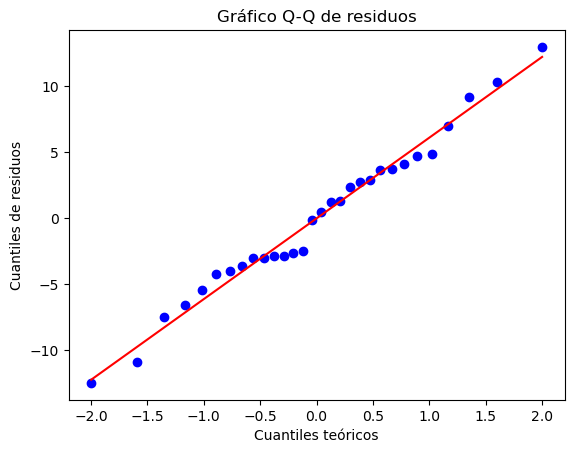

In [13]:
regresion.normalidad_residuos()

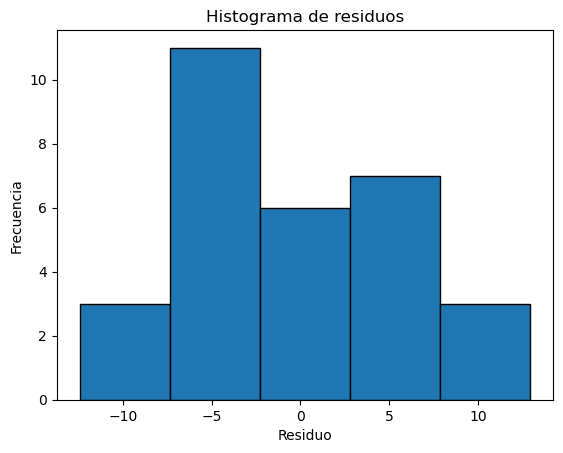

In [14]:
regresion.residuos_histograma()

In [15]:
estadistico, p = regresion.residuos_test()
print("Prueba de Shapiro-Wilk")
print("  Observado: %.4f" % estadistico)
print("  Valor-p  : %.4f" % p)

Prueba de Shapiro-Wilk
  Observado: 0.9839
  Valor-p  : 0.9165


El p-valor es grande, así que **no hay evidencia para rechazar la normalidad** de los residuos.
(Ojo con la lógica invertida: acá un p-valor **grande** es la buena noticia.)

## Homocedasticidad

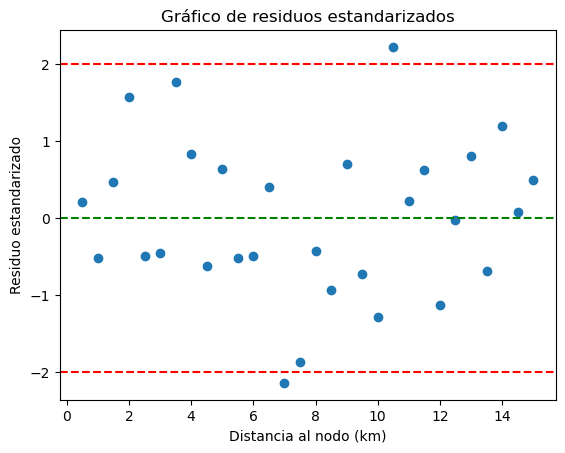

In [16]:
regresion.residuos_estandar()

In [17]:
LM, p = regresion.breusch_pagan()
print("Prueba de Breusch-Pagan")
print("  Observado: %.4f" % LM)
print("  Valor-p  : %.4f" % p)

Prueba de Breusch-Pagan
  Observado: 0.0001
  Valor-p  : 0.9920


**No hay evidencia para rechazar la homocedasticidad.** La banda de residuos mantiene
un ancho parejo y no aparece la forma de embudo.

## Valores atípicos

En el gráfico de residuos estandarizados se ven dos puntos que se pasan de ±2.
Para saber si además son **influyentes** miramos el apalancamiento y la distancia de Cook:

In [18]:
tabla = regresion.atipicos()
tabla[abs(tabla['residuo_estandarizado']) > 2]

,distancia,velocidad,predicho,residuo,residuo_estandarizado,apalancamiento,cook
13,7.0,55.2,67.66,-12.46,-2.1,0.0343,0.0784
20,10.5,60.7,47.73,12.97,2.2,0.0468,0.1189


In [19]:
tabla['cook'].max()

0.1293

Son las conexiones a 7 km y a 10,5 km. En 30 observaciones, encontrar dos casos alrededor
de 2 desvíos es lo esperable bajo normalidad.

Lo que decide es la influencia: **la máxima distancia de Cook es 0,129**, muy por debajo
del valor 1 que se toma como referencia, y ninguna tiene un apalancamiento alto.
**Ninguna observación está condicionando el ajuste**, así que no corresponde excluirlas.

## Independencia

In [20]:
import numpy as np

# Durbin-Watson: cerca de 2 significa que no hay autocorrelacion
e = res['residuo']
dw = ((np.diff(e)) ** 2).sum() / (e ** 2).sum()
print("Durbin-Watson = %.4f" % dw)

Durbin-Watson = 2.0412


---

## Resumen del análisis residual

| Supuesto | Cómo se evaluó | Resultado |
|---|---|---|
| Linealidad | término cuadrático | p = 0,1241 → no aporta ✔ |
| Normalidad | Q-Q plot, histograma, Shapiro-Wilk | p = 0,9165 ✔ |
| Homocedasticidad | residuos estandarizados, Breusch-Pagan | p = 0,9920 ✔ |
| Independencia | Durbin-Watson | 2,0412 ✔ |
| Atípicos | apalancamiento y distancia de Cook | Cook máx = 0,129 → ninguno influyente ✔ |

**Se cumplen los cuatro supuestos**, así que las estimaciones, los p-valores y los
intervalos calculados son válidos.